# Insurance Claim Fraud Detection

## Problem Statement

### 1. Overview of the Question to Be Solved
Insurance companies often experience financial losses due to fraudulent claims. The goal of this project is to detect potential insurance claim fraud by analyzing patterns in policyholder information and accident details. The project aims to build a predictive model that can assign a "risk score" to claims, helping insurance companies identify which cases require further investigation to reduce financial losses.
### 2. Data Needed to Solve the Question
To answer this question, I will use structured claim records that include:

- **Customer demographics**: age, sex, education level, occupation, hobbies, relationship status
- **Policy details**: policy state, CSL, deductible, annual premium, umbrella limit, months as customer
- **Incident information**: incident type, collision type, severity, date, location, authorities contacted, witnesses, police report availability
- **Financial details**: capital gains/losses, total claim amount, injury/property/vehicle claim breakdowns
- **Vehicle information**: auto make, model, year

The dataset (`insurance_claims.csv`) contains **1,000 insurance claim records across 40 features**, with a binary target variable (`fraud_reported`: Y/N) indicating whether each claim was identified as fraudulent.
The fraud rate is **24.7%** (247 fraud vs 753 legitimate).
The [Kaggle dataset Insurance Claim Fraud Detection](https://www.kaggle.com/code/niteshyadav3103/insurance-fraud-detection-using-12-models/data?select=insurance_claims.csv) provides these features and will serve as the primary data source for modeling.

### 3. Techniques
1. **Exploratory Data Analysis (EDA)** – Understanding data patterns, feature distributions, and identifying anomalies.
2. **Classification Models** – KNN, Logistic Regression, Random Forest, Gradient Boosting, and XGBoost
3. **Model Evaluation Techniques** – Using accuracy, precision, recall, F1, confusion matrix, ROC AUC, and Precision-Recall curves to assess model performance.

### 4. Why This Question Is Important
Insurance fraud costs the U.S. insurance industry an estimated $308.6 billion annually. A predictive model that reliably flags suspicious claims enables insurers to prioritize investigations, reduce financial losses, and ultimately lower premiums for honest policyholders. The techniques demonstrated here are transferable across fraud detection domains including healthcare, credit card, and financial services.

### Importing libraries and data

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score

import warnings
warnings.filterwarnings("ignore")

In [71]:
df = pd.read_csv('data/insurance_claims.csv')

## 1. Exploratory Data Analysis

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [73]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [74]:
# Replace missing values '?' with np.nan

df.replace('?', np.nan, inplace = True)

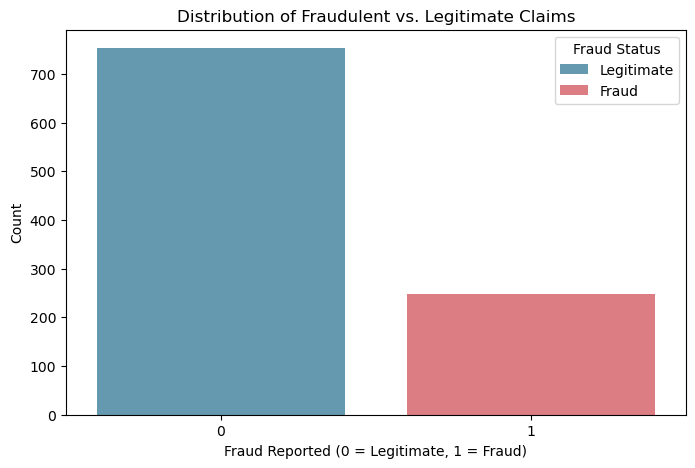

Legitimate: 753 (75.3%)
Fraud:      247 (24.7%)
Imbalance ratio: 3.0 : 1


In [75]:
# Convert target to numeric for plotting
df['fraud_target'] = (df['fraud_reported'] == 'Y').astype(int)

colors = {0: "#2E86AB", 1: "#E84855"}
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='fraud_target', hue='fraud_target', palette=colors, alpha=0.8)
plt.legend(title='Fraud Status', labels=['Legitimate', 'Fraud'])
plt.title('Distribution of Fraudulent vs. Legitimate Claims')
plt.xlabel('Fraud Reported (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

print(f"Legitimate: {(df['fraud_target']==0).sum()} ({(df['fraud_target']==0).mean()*100:.1f}%)")
print(f"Fraud:      {(df['fraud_target']==1).sum()} ({(df['fraud_target']==1).mean()*100:.1f}%)")
print(f"Imbalance ratio: {(df['fraud_target']==0).sum() / (df['fraud_target']==1).sum():.1f} : 1")

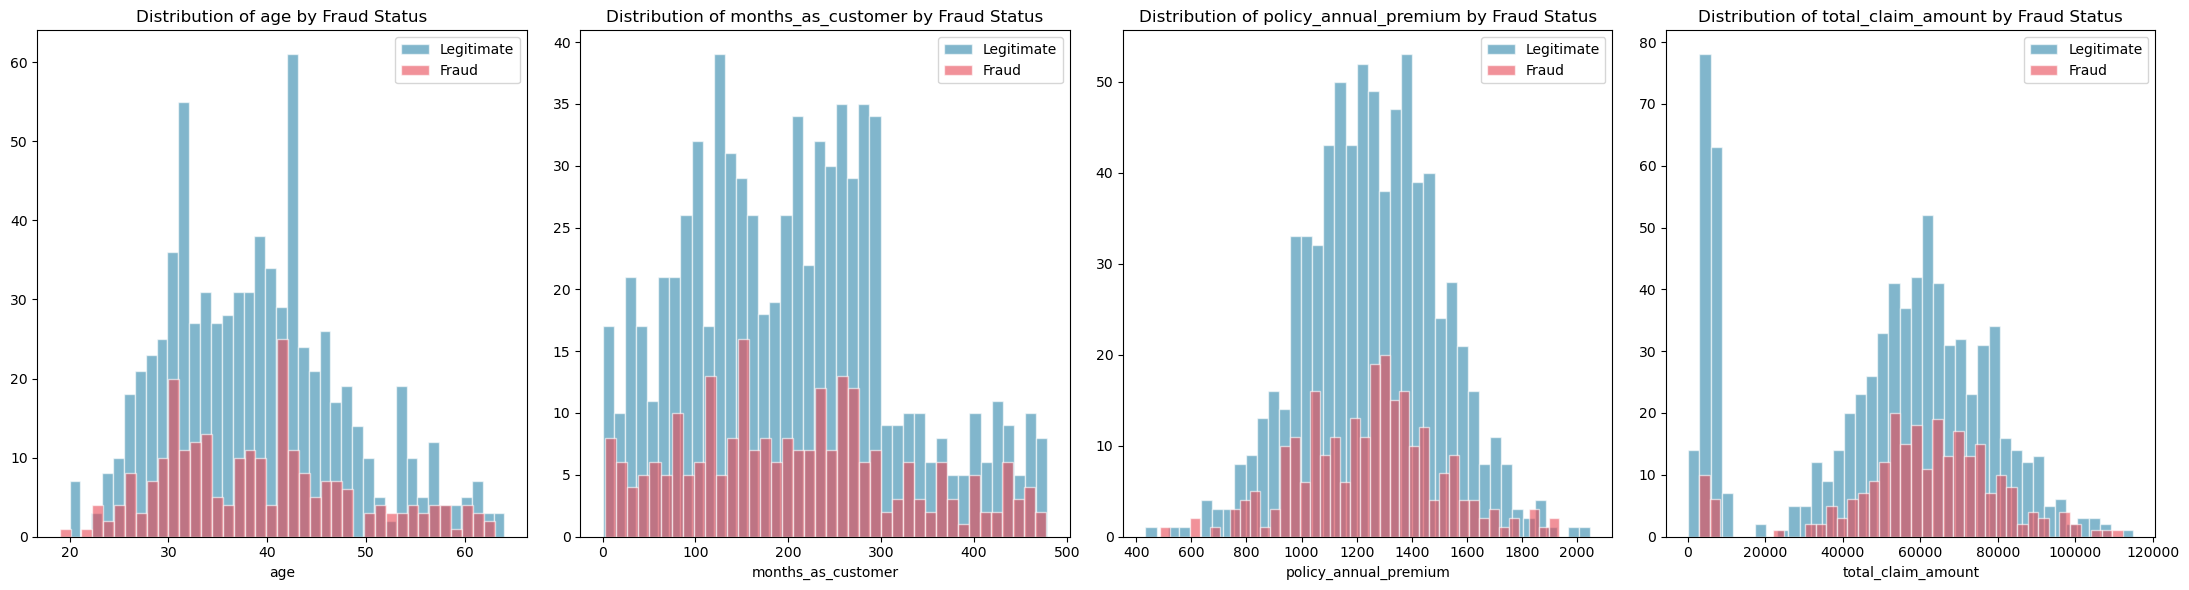

In [76]:
# Numerical features for visualization
numeric_cols = ['age', 'months_as_customer', 'policy_annual_premium', 'total_claim_amount']

# Plot distributions for numerical features
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(22, 6))

for i, col in enumerate(numeric_cols):
    for label, color in colors.items():
        subset = df[df['fraud_target'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                    label='Fraud' if label == 1 else 'Legitimate', edgecolor='white')
    axes[i].set_title(f"Distribution of {col} by Fraud Status", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

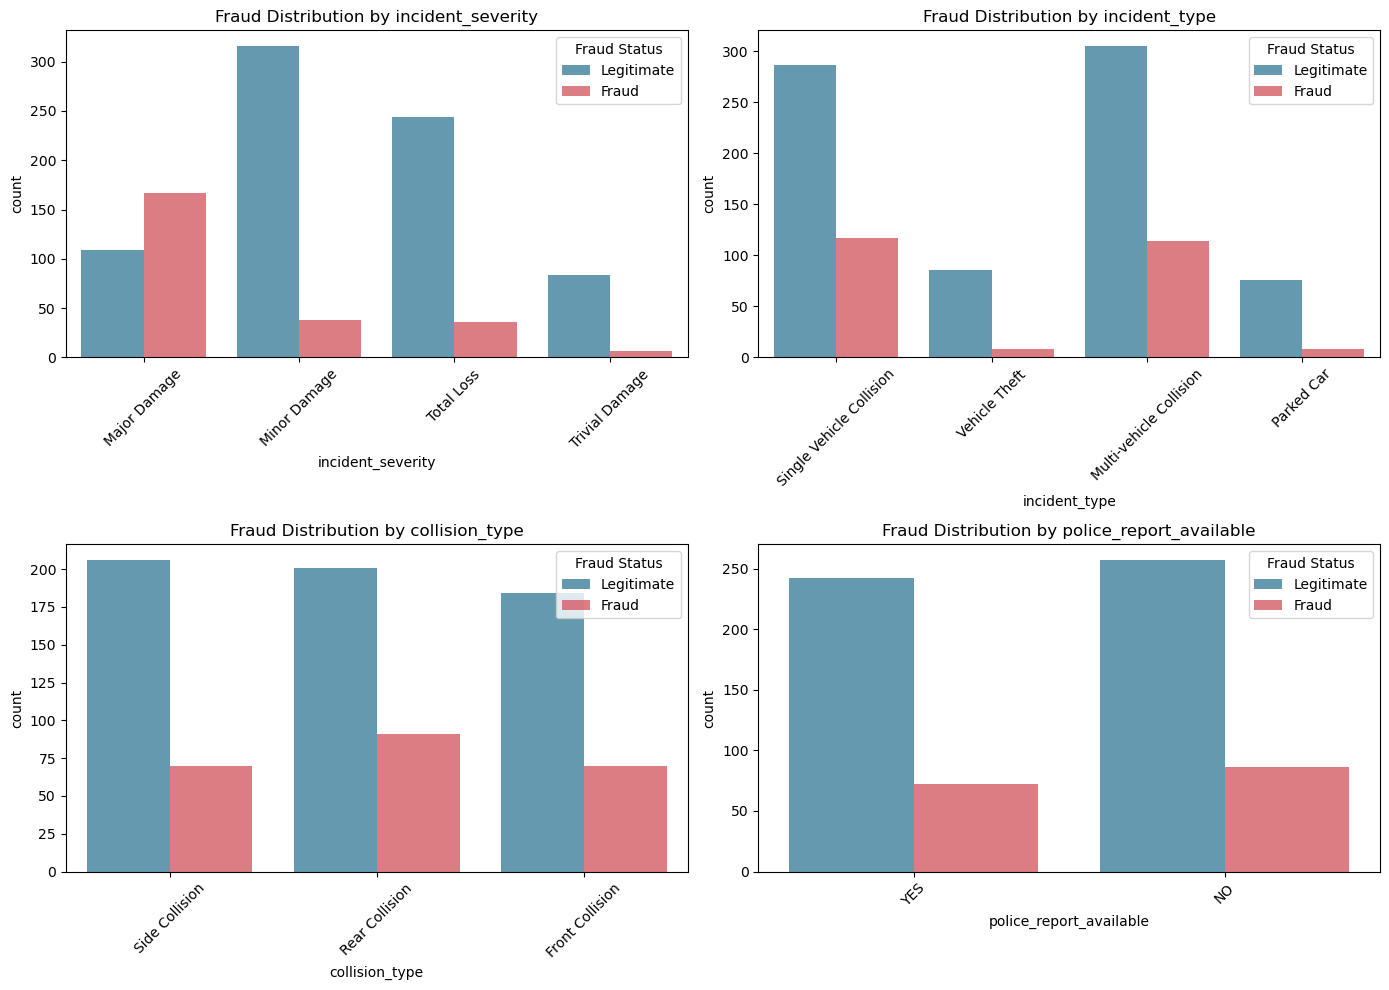

In [77]:
# Plot categorical features against the target variable
categorical_cols = ['incident_severity', 'incident_type', 'collision_type', 'police_report_available']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='fraud_target', data=df, ax=axes[i], palette=colors, alpha=0.8)
    axes[i].set_title(f'Fraud Distribution by {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Fraud Status', labels=['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

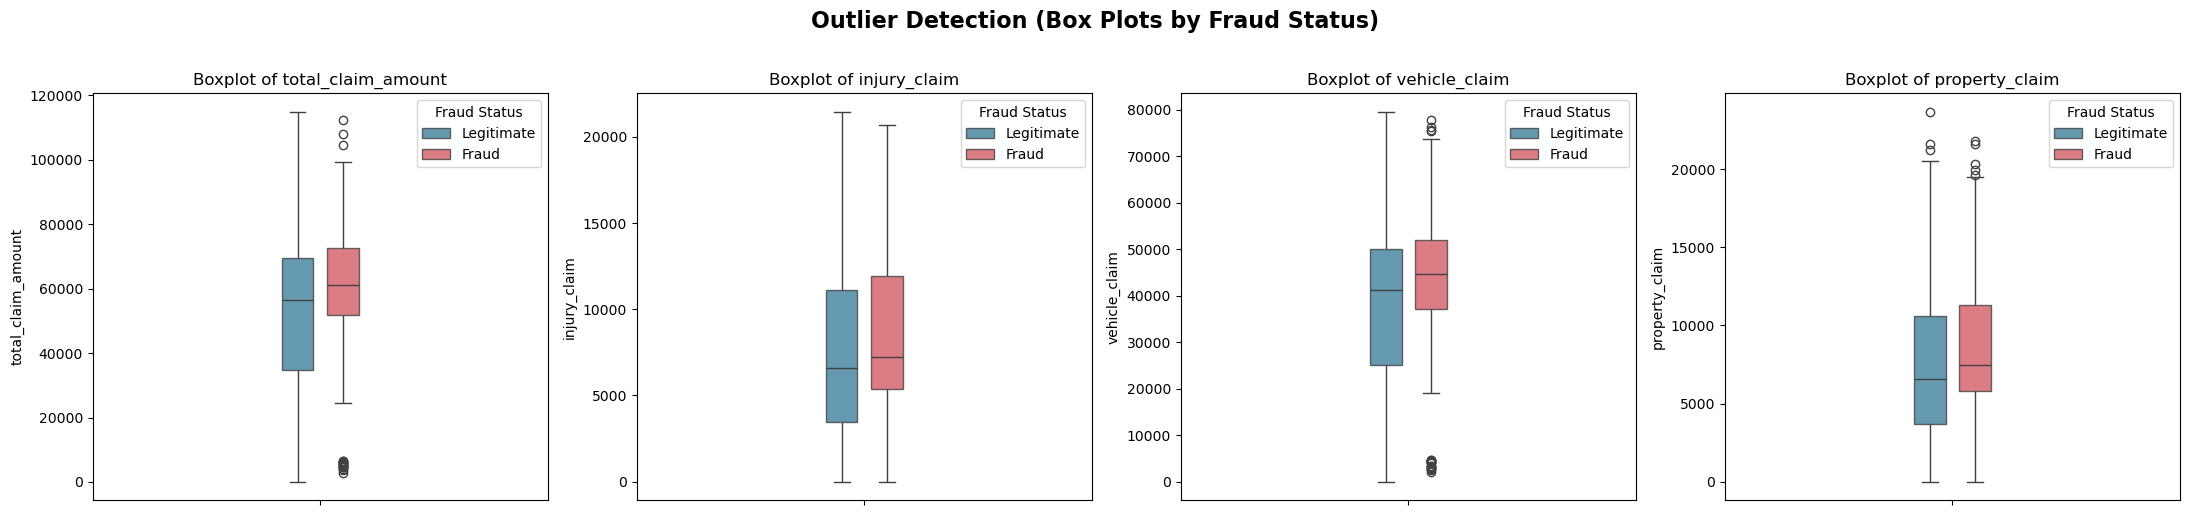

In [78]:
# Identify outliers in numerical data
box_cols = ['total_claim_amount', 'injury_claim', 'vehicle_claim', 'property_claim']

fig, axes = plt.subplots(1, len(box_cols), figsize=(22, 5))
fig.suptitle("Outlier Detection (Box Plots by Fraud Status)", fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(box_cols):
    sns.boxplot(y=df[col], ax=axes[i], hue=df['fraud_target'], palette=colors,
                width=0.2, gap=0.3, boxprops=dict(alpha=0.8))
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].legend(title='Fraud Status', labels=['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

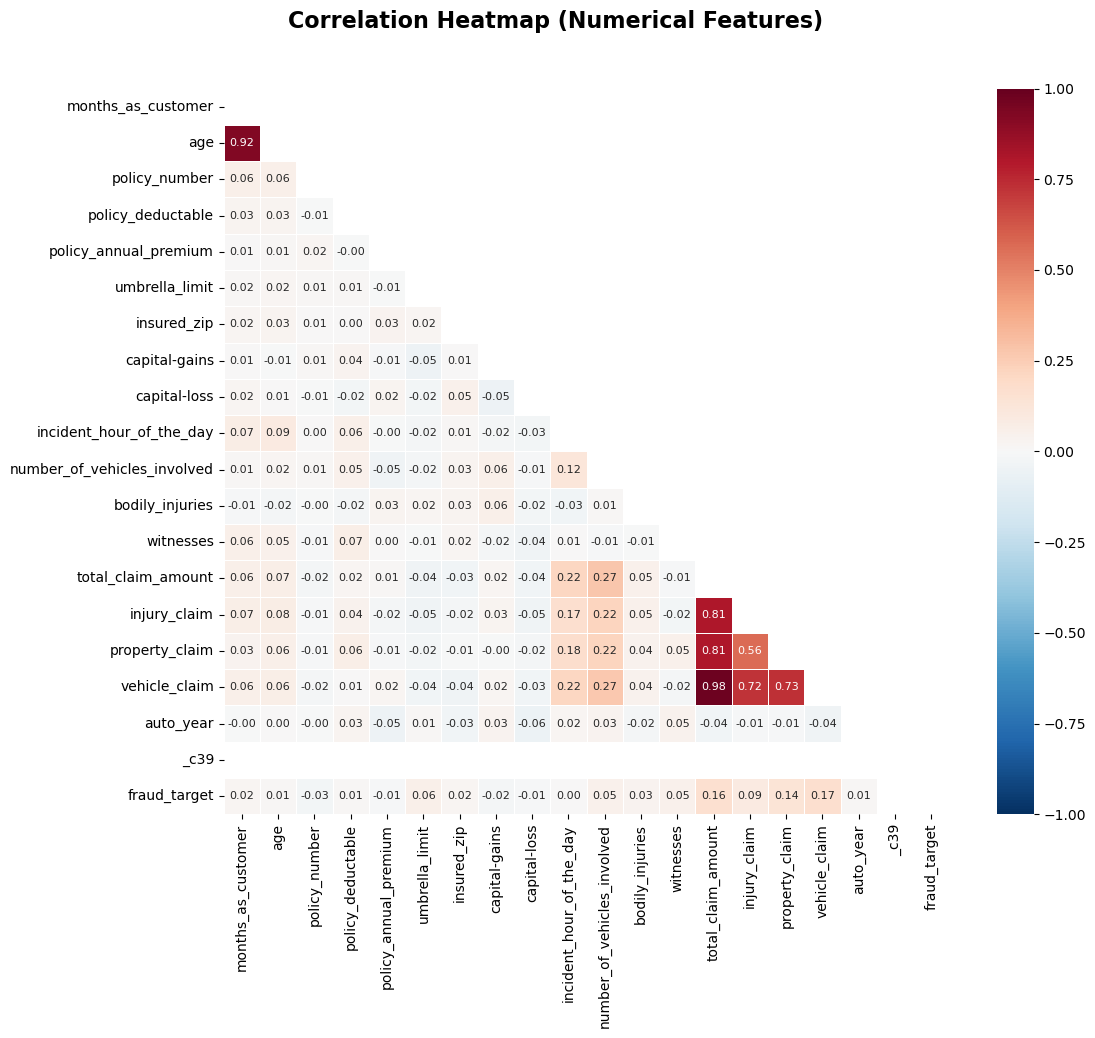

In [79]:
# Correlation Heatmap (Numerical Features)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle("Correlation Heatmap (Numerical Features)", fontsize=16, fontweight='bold', y=1.02)
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
plt.tight_layout()
plt.show()

### Findings:
1. **Moderate Class Imbalance**: The dataset has a 75/25 split between legitimate and fraudulent claims (3:1 ratio). 

2. **Strong Signal Features**: This data contains features with strong predictive power:
   - **Incident severity** has the highest mutual information with fraud (MI = 0.12). Major Damage claims show distinctly higher fraud rates.
   - **Claim amount features** (total_claim_amount, injury_claim, property_claim, vehicle_claim) provide rich continuous signals for the models.
   - **Incident type** (Single Vehicle Collision, Vehicle Theft, etc.) shows clear fraud rate variation.

3. **Missing Values**: The `collision_type`, `property_damage`, and `police_report_available` columns contain NA values that must be handled. The `authorities_contacted` column has 91 null values (9.1%).
4. **High Correlations**: injury_claim, property_claim, vehicle_claim are strongly correlated with total_claim_amount since they sum to it. Additionally, age and months_as_customer show a strong correlation.


### Data preprocessing

In [80]:
#Data Cleaning 
# Drop non-predictive columns
drop_cols = ['policy_number', 'incident_location', 'policy_bind_date',
             'incident_date', '_c39', 'fraud_reported']
df = df.drop(columns=drop_cols)

# Replace '?' placeholders with NaN, then fill with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill remaining NaN (authorities_contacted)
df = df.fillna(df.mode().iloc[0])

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"Dataset shape: {df.shape}")

#Train-Test Split 
X = df.drop('fraud_target', axis=1)
y = df['fraud_target']

#stratify=y ensures both sets maintain the original fraud ratio before we balance the train set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Preprocessing Pipeline 
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"\nFeature dimensions after encoding: {X_train_processed.shape[1]} features")

#Apply SMOTE to the Training Set only
print("\nClass Imbalance BEFORE SMOTE (Training Set)")
print(y_train.value_counts(normalize=True) * 100)
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("\nClass Distribution after SMOTE (Training Set)")
print(y_train_smote.value_counts(normalize=True) * 100)
print(y_train_smote.value_counts())

Missing values after cleaning: 0
Dataset shape: (1000, 35)

Feature dimensions after encoding: 158 features

Class Imbalance BEFORE SMOTE (Training Set)
fraud_target
0    75.25
1    24.75
Name: proportion, dtype: float64
fraud_target
0    602
1    198
Name: count, dtype: int64

Class Distribution after SMOTE (Training Set)
fraud_target
0    50.0
1    50.0
Name: proportion, dtype: float64
fraud_target
0    602
1    602
Name: count, dtype: int64


### Models

Training: Logistic Regression
  Best Params: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1:  0.8849035228666343
  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.85      0.85      0.85       151
       Fraud       0.54      0.55      0.55        49

    accuracy                           0.78       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.78      0.78      0.78       200

Training: KNN
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
  Best CV F1:  0.7235932390488534
  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.81      0.19      0.31       151
       Fraud       0.26      0.86      0.39        49

    accuracy                           0.35       200
   macro avg       0.53      0.52      0.35       200
weighted avg       0.67      0.35      0.33       200

Training: Random Fores

Training: Logistic Regression
  Best Params: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1:  0.8849035228666343
  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.85      0.85      0.85       151
       Fraud       0.54      0.55      0.55        49

    accuracy                           0.78       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.78      0.78      0.78       200

Training: KNN
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
  Best CV F1:  0.7235932390488534
  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.81      0.19      0.31       151
       Fraud       0.26      0.86      0.39        49

    accuracy                           0.35       200
   macro avg       0.53      0.52      0.35       200
weighted avg       0.67      0.35      0.33       200

Training: Random Fores

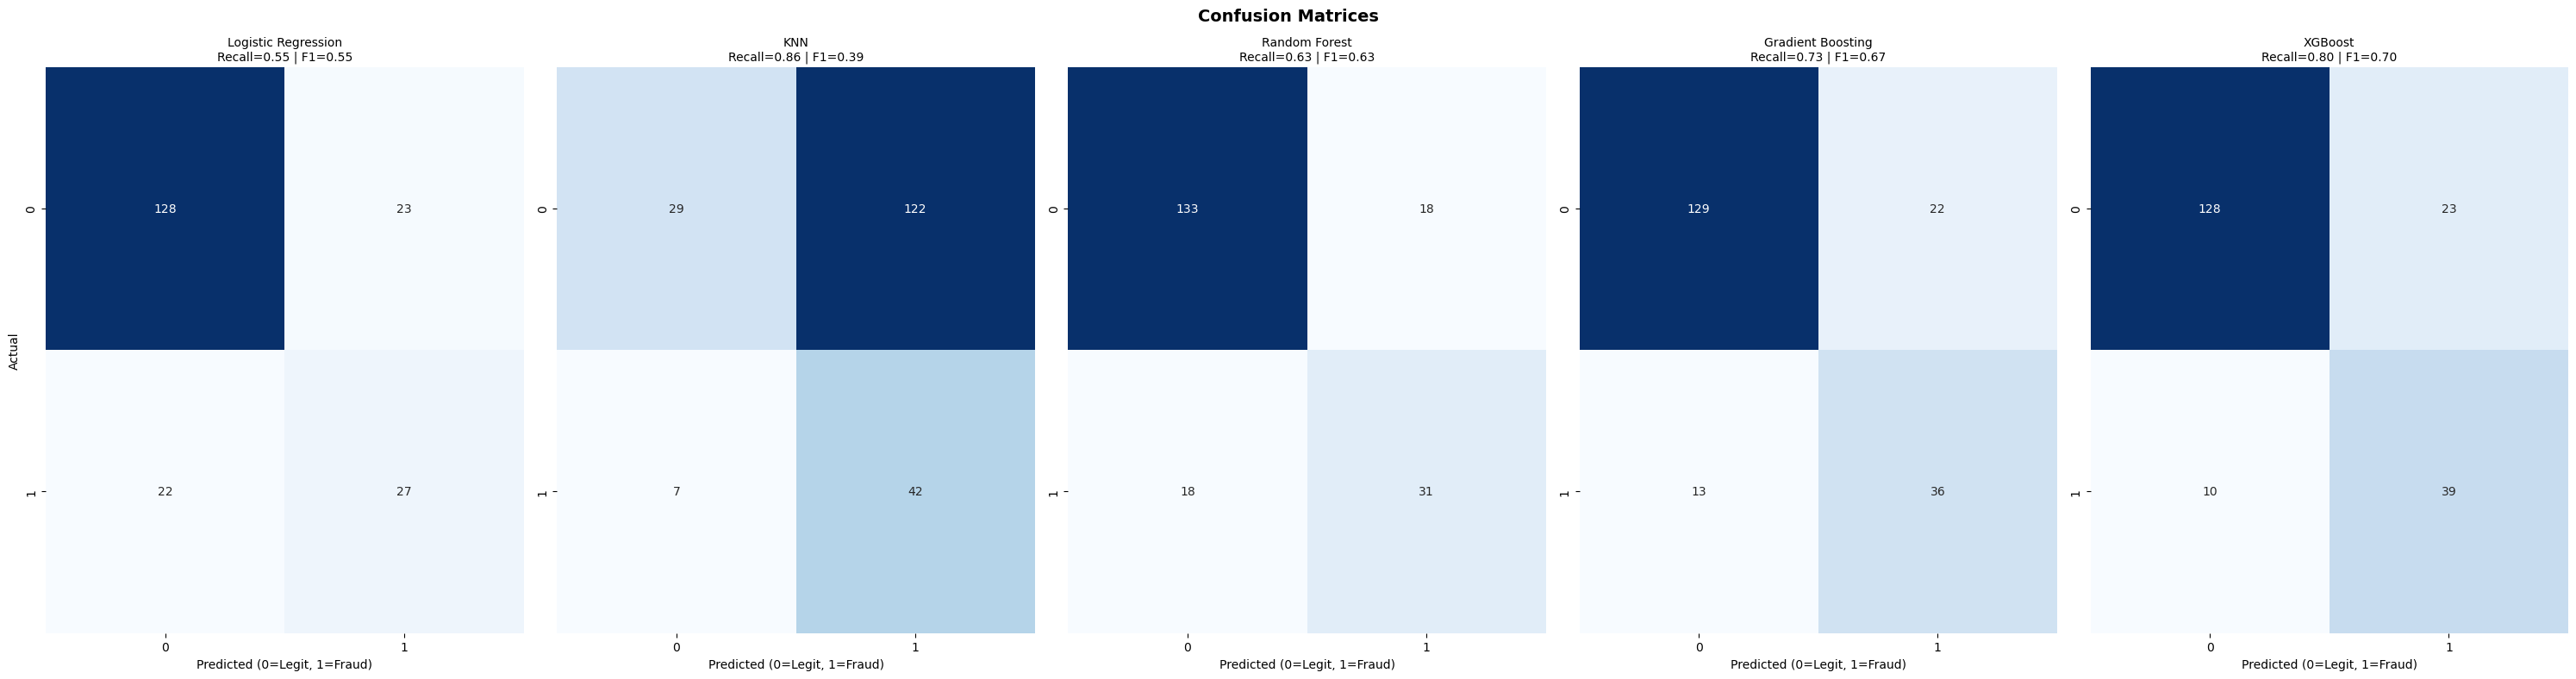

Training: Logistic Regression
  Best Params: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1:  0.8849035228666343
  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.85      0.85      0.85       151
       Fraud       0.54      0.55      0.55        49

    accuracy                           0.78       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.78      0.78      0.78       200

Training: KNN
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
  Best CV F1:  0.7235932390488534
  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.81      0.19      0.31       151
       Fraud       0.26      0.86      0.39        49

    accuracy                           0.35       200
   macro avg       0.53      0.52      0.35       200
weighted avg       0.67      0.35      0.33       200

Training: Random Fores

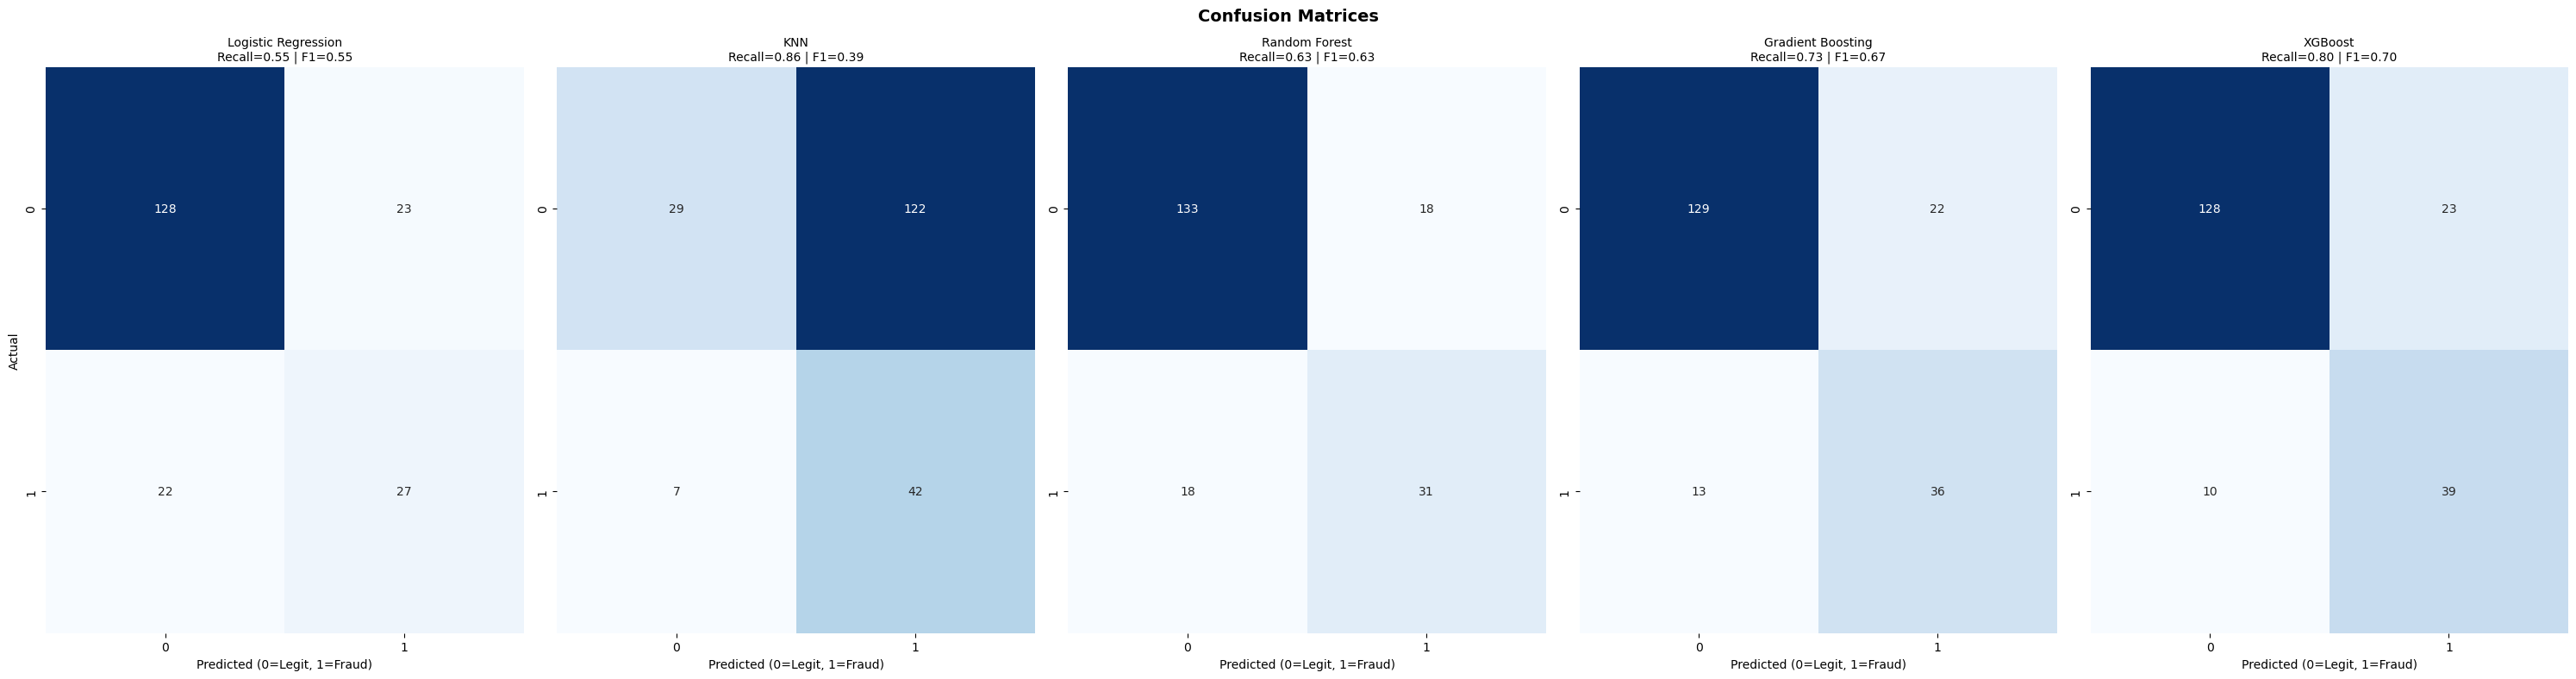

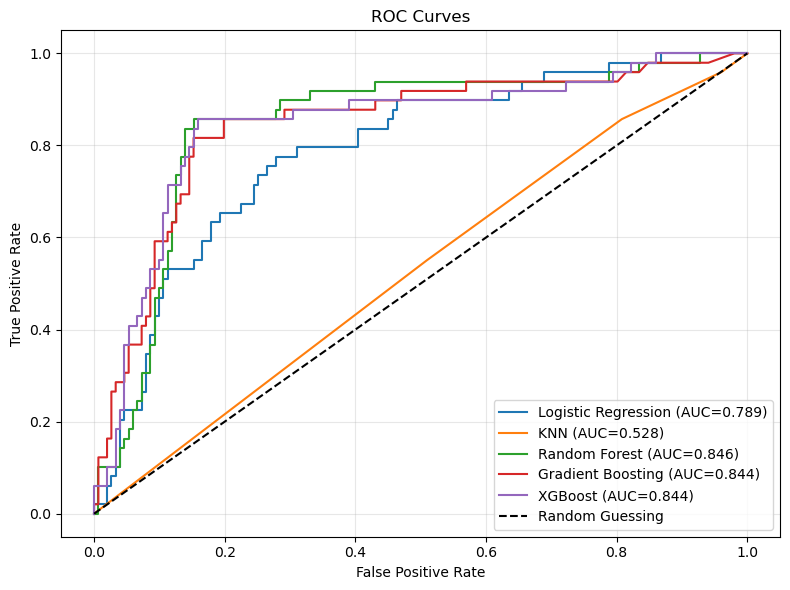

Training: Logistic Regression
  Best Params: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1:  0.8849035228666343
  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.85      0.85      0.85       151
       Fraud       0.54      0.55      0.55        49

    accuracy                           0.78       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.78      0.78      0.78       200

Training: KNN
  Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
  Best CV F1:  0.7235932390488534
  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.81      0.19      0.31       151
       Fraud       0.26      0.86      0.39        49

    accuracy                           0.35       200
   macro avg       0.53      0.52      0.35       200
weighted avg       0.67      0.35      0.33       200

Training: Random Fores

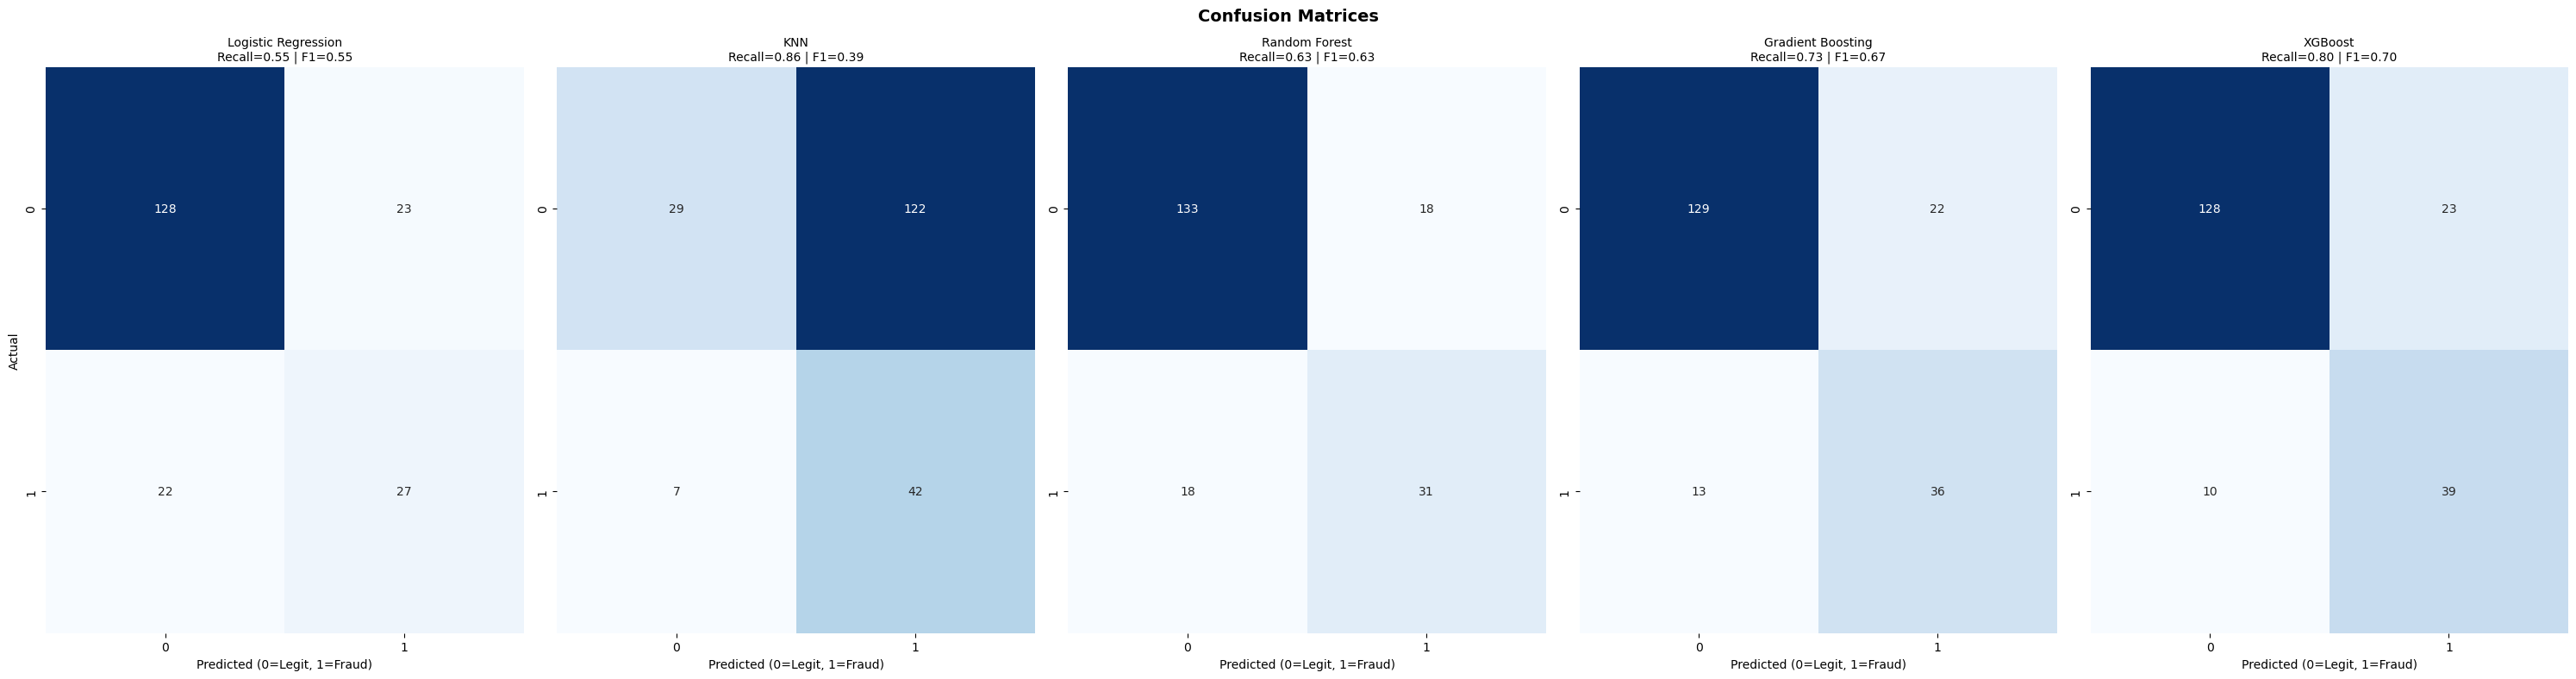

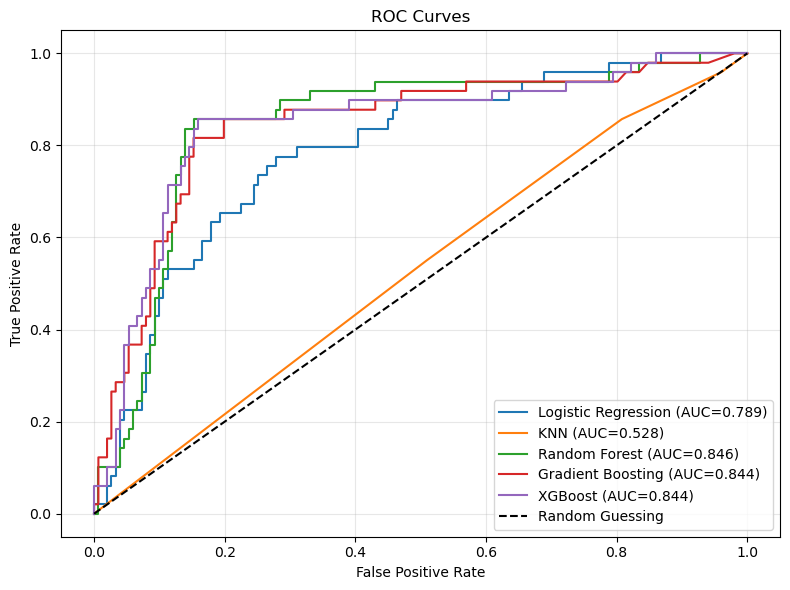

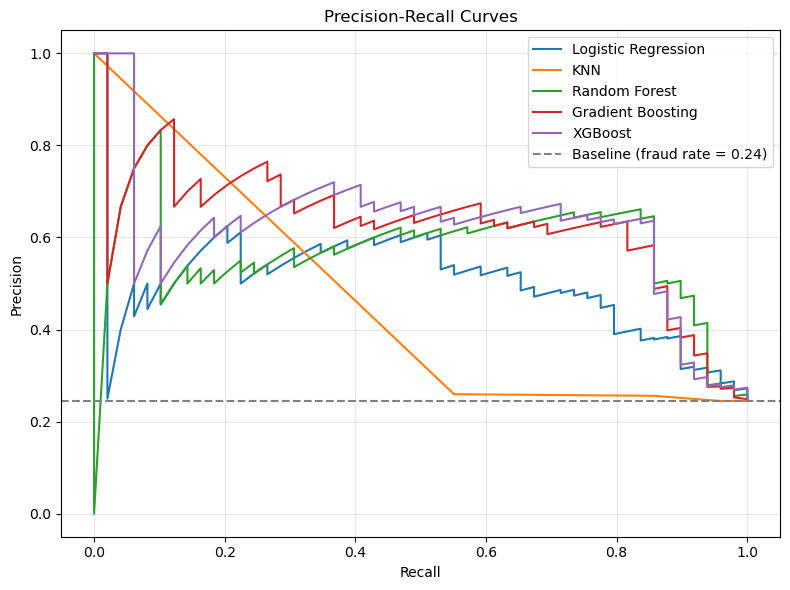

In [81]:
# Define parameter grids for each model
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"],
        "max_iter": [1000]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11, 15],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean"]
    },
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [5, 10],
        "min_samples_leaf": [1, 2, 4],
        "min_samples_split": [2, 5]
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "min_samples_split": [2, 5],
        "subsample": [0.8, 1.0]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "min_child_weight": [1, 3],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
best_models = {}

# Setup figure for Confusion Matrices
fig_cm, axes_cm = plt.subplots(1, 5, figsize=(28, 5.5))
fig_cm.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for i, (name, model) in enumerate(models.items()):
    print(f"Training: {name}")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring="f1",
        cv=5,
        n_jobs=-1
    )
    grid_search.fit(X_train_smote, y_train_smote)

    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    print(f"  Best Params: {grid_search.best_params_}")
    print(f"  Best CV F1:  {grid_search.best_score_}")

    # Predictions
    y_pred = best_model.predict(X_test_processed)
    y_proba = best_model.predict_proba(X_test_processed)[:, 1]

    print(f"  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Legitimate', 'Fraud']))

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Best Params": str(grid_search.best_params_),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i], cbar=False)
    axes_cm[i].set_title(f'{name}\nRecall={rec:.2f} | F1={f1:.2f}', fontsize=10)
    axes_cm[i].set_xlabel('Predicted (0=Legit, 1=Fraud)')
    axes_cm[i].set_ylabel('Actual' if i == 0 else '')

plt.tight_layout()
plt.show()

#ROC Curves 
plt.figure(figsize=(8, 6))
for name, best_model in best_models.items():
    y_proba = best_model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Precision-Recall Curves
plt.figure(figsize=(8, 6))
for name, best_model in best_models.items():
    y_proba = best_model.predict_proba(X_test_processed)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall_vals, precision_vals, label=f'{name}')

plt.axhline(y=y_test.mean(), color='gray', linestyle='--',
            label=f'Baseline (fraud rate = {y_test.mean():.2f})')
plt.title('Precision-Recall Curves')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

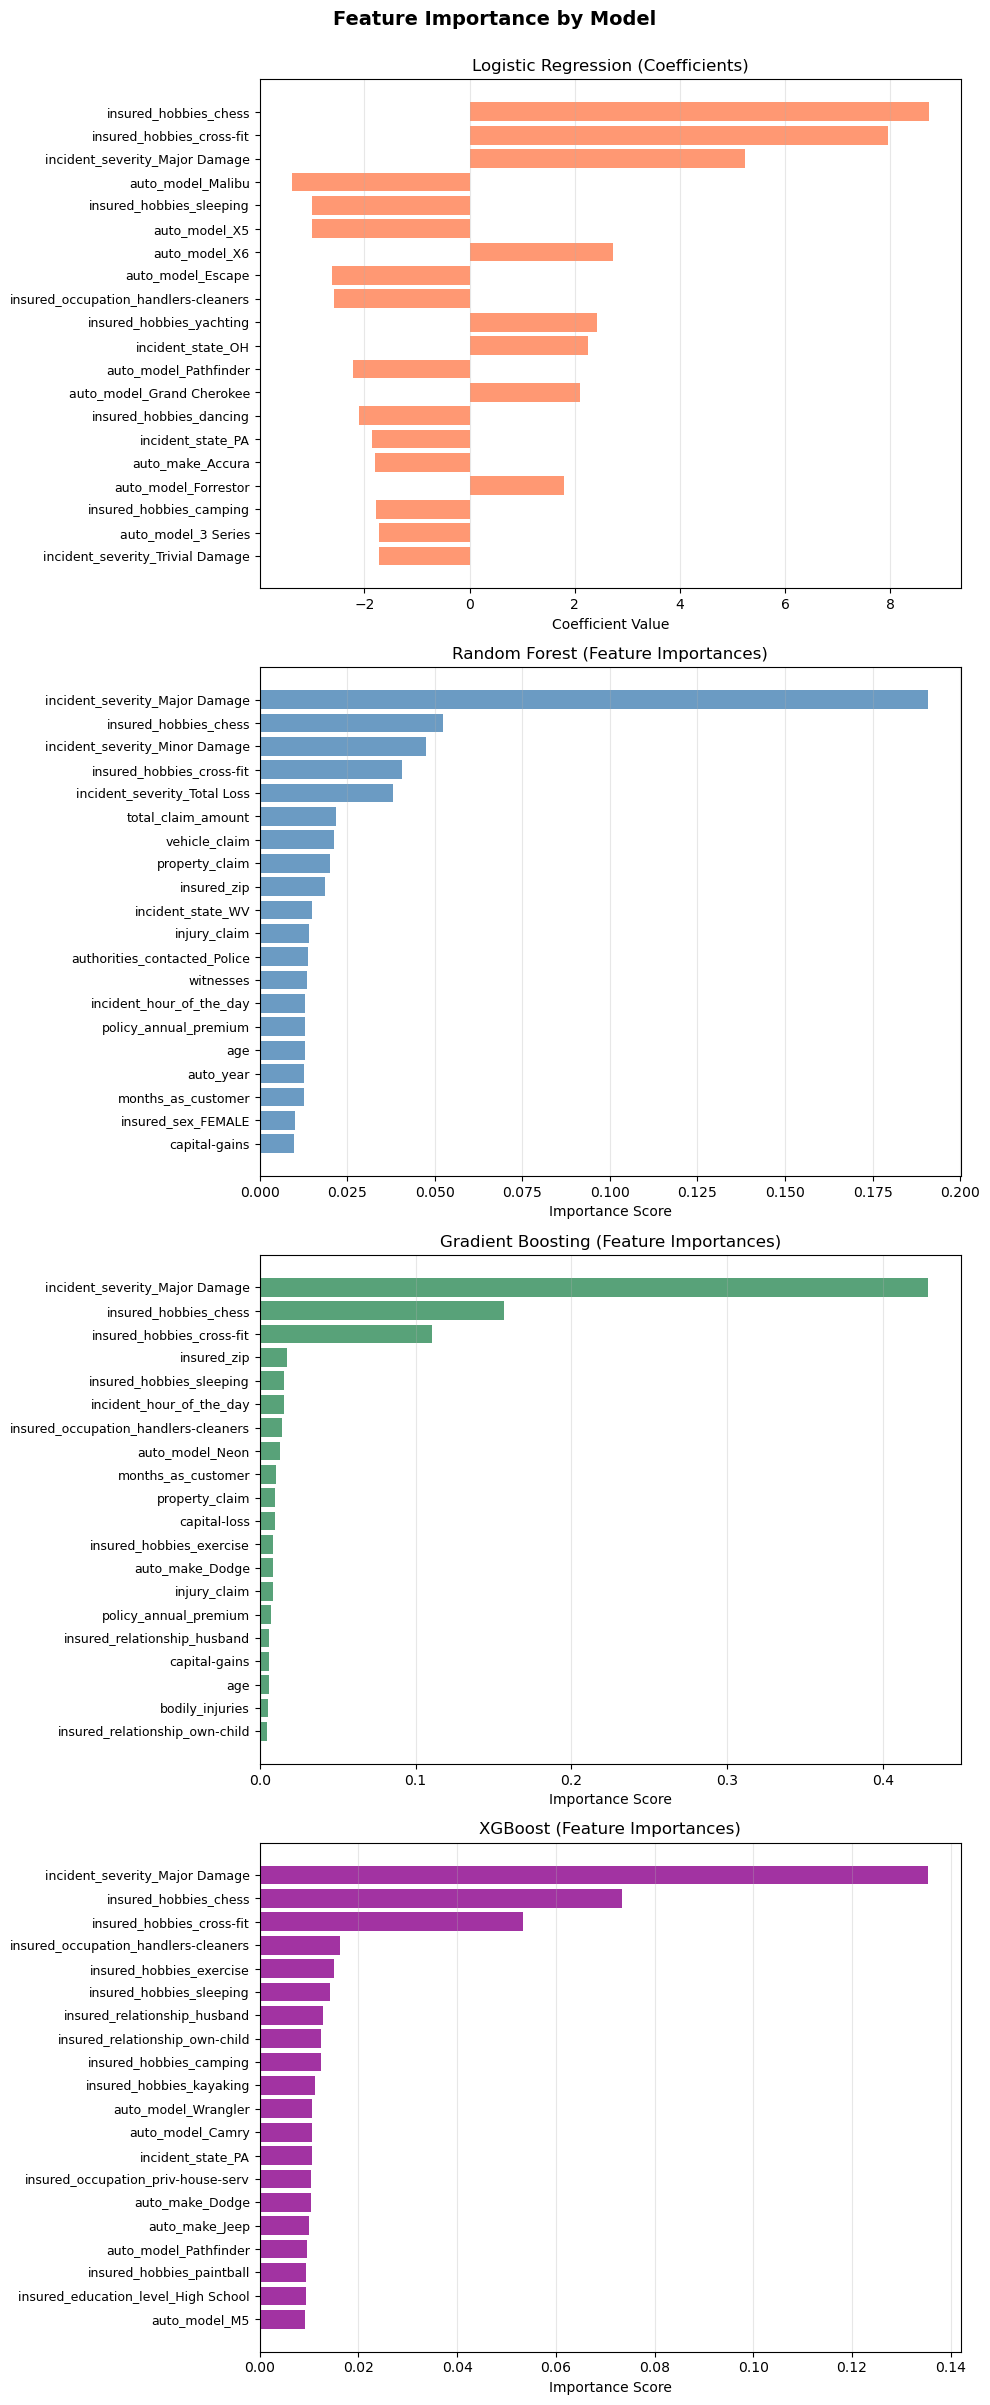

Tuned Model Performance Comparison


,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Model,,,,,,
Logistic Regression,0.775,0.5400,0.5510,0.5455,0.7886,0.5110
KNN,0.355,0.2561,0.8571,0.3944,0.5276,0.2564
Random Forest,0.820,0.6327,0.6327,0.6327,0.8455,0.5805
Gradient Boosting,0.825,0.6207,0.7347,0.6729,0.8436,0.6343
XGBoost,0.835,0.6290,0.7959,0.7027,0.8443,0.6285



Best Hyperparameters


,Best Params
Model,
Logistic Regression,"{'C': 10, 'max_iter': 1000, 'penalty': 'l1', '..."
KNN,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei..."
Random Forest,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
Gradient Boosting,"{'learning_rate': 0.01, 'max_depth': 7, 'min_s..."
XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


In [61]:
#Feature Importance 
feature_names = (
    num_cols +
    preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
)

fig, axes = plt.subplots(4, 1, figsize=(10, 24))
fig.suptitle('Feature Importance by Model', y=1, fontsize=14, fontweight='bold')

plot_idx = 0
importance_colors = {
    "Logistic Regression": "coral",
    "Random Forest": "steelblue",
    "Gradient Boosting": "seagreen",
    "XGBoost": "darkmagenta"
}

for name, best_model in best_models.items():
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[-20:]
        axes[plot_idx].barh(
            [feature_names[j] for j in indices],
            importances[indices],
            color=importance_colors.get(name, "lightblue"), alpha=0.8
        )
        axes[plot_idx].set_title(f'{name} (Feature Importances)')
        axes[plot_idx].set_xlabel('Importance Score')
        plot_idx += 1

    elif hasattr(best_model, 'coef_'):
        importances = best_model.coef_[0]
        indices = np.argsort(np.abs(importances))[-20:]
        axes[plot_idx].barh(
            [feature_names[j] for j in indices],
            importances[indices],
            color=importance_colors.get(name, "lightcoral"), alpha=0.8
        )
        axes[plot_idx].set_title(f'{name} (Coefficients)')
        axes[plot_idx].set_xlabel('Coefficient Value')
        plot_idx += 1

for i in range(4):
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

#Results Table
results_df = pd.DataFrame(results).set_index("Model")
print("Tuned Model Performance Comparison")
display(results_df.drop(columns=["Best Params"]).round(4))
print("\nBest Hyperparameters")
display(results_df[["Best Params"]])

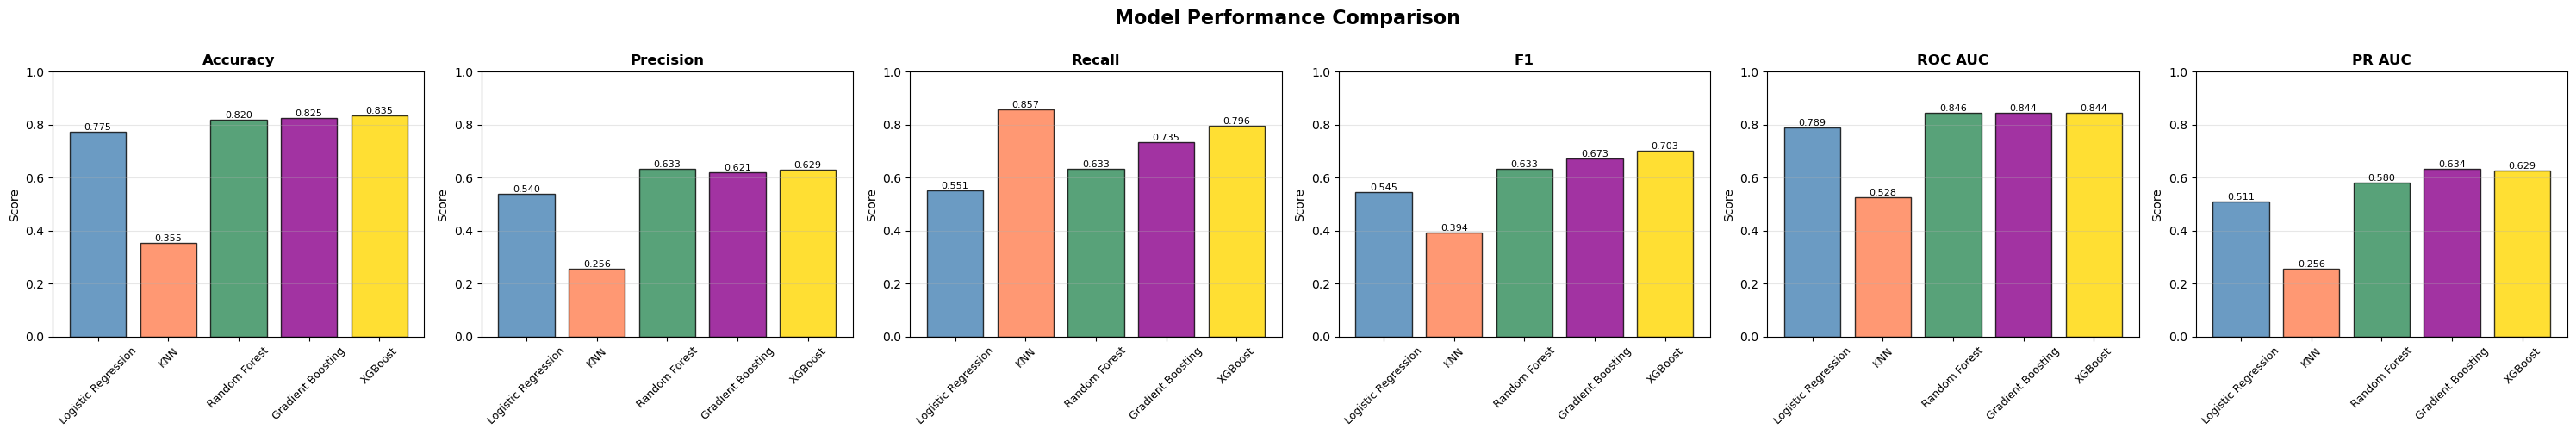

Model Performance Analysis
Best Model per Metric:
Accuracy: XGBoost (0.8350)
Precision: Random Forest (0.6327)
Recall: XGBoost (0.7959)
F1: XGBoost (0.7027)
ROC AUC: Random Forest (0.8455)
PR AUC: Gradient Boosting (0.6343)
-----------------------------------
Best Overall Model (F1):
XGBoost
F1 Score: 0.7027
Accuracy: 0.8350
Precision: 0.6290
Recall: 0.7959
-----------------------------------
Best Fraud Catcher (Recall):
XGBoost
Recall: 0.7959
F1 Score: 0.7027
Precision: 0.6290
Accuracy: 0.8350


In [83]:
# Model Performance Comparison
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC', 'PR AUC']

# Create subplots for each metric
fig, axes = plt.subplots(1, len(metric_names), figsize=(30, 5))
fig.suptitle("Model Performance Comparison", fontsize=16, fontweight='bold', y=1)

model_colors = ['steelblue', 'coral', 'seagreen', 'darkmagenta', 'gold', 'darkorange']

for idx, metric in enumerate(metric_names):
    metric_values = results_df[metric].values
    model_names = results_df.index.tolist()
    
    bars = axes[idx].bar(model_names, metric_values, color=model_colors, alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score', fontsize=10)
    axes[idx].set_ylim([0, 1])
    axes[idx].tick_params(axis='x', rotation=45, labelsize=9)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Annotate bars with values
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.3f}',
                      ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print Best Models Analysis
print("Model Performance Analysis")

# Filter out models with AUC near random (< 0.60)
filtered_models = results_df[results_df['ROC AUC'] >= 0.60]
print("Best Model per Metric:")
for metric in metric_names:
    best_model = filtered_models[metric].idxmax()
    best_score = filtered_models[metric].max()
    print(f"{metric}: {best_model} ({best_score:.4f})")


print("-----------------------------------")
print("Best Overall Model (F1):")
best_f1_model = filtered_models['F1'].idxmax()
best_f1_score = filtered_models['F1'].max()
print(f"{best_f1_model}")
print(f"F1 Score: {best_f1_score:.4f}")
print(f"Accuracy: {filtered_models.loc[best_f1_model, 'Accuracy']:.4f}")
print(f"Precision: {filtered_models.loc[best_f1_model, 'Precision']:.4f}")
print(f"Recall: {filtered_models.loc[best_f1_model, 'Recall']:.4f}")

print("-----------------------------------")
print("Best Fraud Catcher (Recall):")
best_recall_model = filtered_models['Recall'].idxmax()
best_recall_score = filtered_models['Recall'].max()
print(f"{best_recall_model}")
print(f"Recall: {best_recall_score:.4f}")
print(f"F1 Score: {filtered_models.loc[best_recall_model, 'F1']:.4f}")
print(f"Precision: {filtered_models.loc[best_recall_model, 'Precision']:.4f}")
print(f"Accuracy: {filtered_models.loc[best_recall_model, 'Accuracy']:.4f}")

## Conclusion

### Best Model Recommendation

- **XGBoost** is the recommended model for insurance claim fraud detection. It achieved the best overall balance of performance across all key metrics:<br />
F1 Score: 0.7027<br />
Accuracy: 0.8350<br />
Precision: 0.6290<br />
Recall: 0.7959<br />
ROC AUC: 0.8443<br />

- XGBoost catches approximately 80% of all fraudulent claims while maintaining 63% precision. It means 2 out of every 3 claims it flags turn out to be actual fraud. For an insurance company, that means investigators spend less time chasing false leads and more time on cases that matter.

### What I Learned

- Not all high-performing metrics tell the truth. KNN, for example, scored the highest recall at 86%, which initially looked impressive. But when I dug deeper, I realized it was achieving that by flagging nearly everything as fraud. Its accuracy is just 35% and its ROC AUC of 0.53 was barely better than flipping a coin. This taught me that you really have to look at multiple metrics together before drawing conclusions.

- The results confirmed what the EDA suggested early on. Incident severity and claim amounts are the strongest fraud signals. All three ensemble models consistently ranked these at the top of their feature importance lists.

### Future Work

- **Threshold tuning:** Adjust the classification threshold beyond the default 0.50 to optimize the precision-recall tradeoff for specific business requirements.
- **Larger datasets:** Validate the approach on a larger dataset to confirm these patterns hold up at scale.